# Exploratory Data Analysis

This notebook explores divorce patterns in the IPUMS USA dataset. The main question is whether demographic and socio-economic variables such as age, education, employment, and income are related to divorce status.

The target variable is:

- `divorced = 1`: divorced or separated
- `divorced = 0`: married, widowed, or spouse absent

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

## 1. Load Data

The raw CSV file is large, so I keep it in a local `data/` folder instead of uploading it directly to GitHub.

In [4]:
DATA_PATH = "data/usa_00001.csv"

df = pd.read_csv(DATA_PATH)
print("Original shape:", df.shape)
df.head()

Original shape: (3405809, 20)


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,PERWT,SEX,AGE,MARST,EDUC,EDUCD,EMPSTAT,EMPSTATD,INCWAGE,POVERTY
0,2023,202301,1,2023010000113,6.0,2023000000011,41,280201,3,1,6.0,2,86,5,6,63,3,30,0,0
1,2023,202301,2,2023010000180,27.0,2023000000021,41,10001,3,1,27.0,1,60,6,6,63,3,30,0,0
2,2023,202301,3,2023010000181,47.0,2023000000031,41,40201,4,1,47.0,1,20,6,7,71,3,30,0,0
3,2023,202301,4,2023010000250,11.0,2023000000041,41,270201,3,1,11.0,2,13,6,2,26,0,0,999999,0
4,2023,202301,5,2023010000340,57.0,2023000000051,41,280201,4,1,57.0,1,18,6,6,65,3,30,2500,0


## 2. Cleaning and Target Variable

I keep adults only. I also remove people who were never married because they are not at risk of being divorced in the same way as people who have been married before.

In [6]:
# Keep adults only
if "AGE" in df.columns:
    df = df[df["AGE"] >= 18].copy()

# Remove never-married people when MARST is available
if "MARST" in df.columns:
    df = df[df["MARST"] != 6].copy()
    df["divorced"] = df["MARST"].isin([3, 4]).astype(int)
else:
    raise ValueError("MARST column is needed to create the divorce target variable.")

print("Cleaned shape:", df.shape)
print(df["divorced"].value_counts(normalize=True))

Cleaned shape: (2002392, 21)
divorced
0    0.827171
1    0.172829
Name: proportion, dtype: float64


## 3. Feature Preparation for EDA

I create a few simple variables to make the charts easier to read. These are also useful later for the machine learning notebook.

In [8]:
# Income transformation: income is usually very skewed
if "INCWAGE" in df.columns:
    df["INCWAGE"] = pd.to_numeric(df["INCWAGE"], errors="coerce")
    df.loc[df["INCWAGE"] < 0, "INCWAGE"] = np.nan
    df["log_income"] = np.log1p(df["INCWAGE"].fillna(0))

    try:
        df["income_group"] = pd.qcut(
            df["INCWAGE"].fillna(0),
            q=4,
            labels=["Low", "Lower-Middle", "Upper-Middle", "High"],
            duplicates="drop"
        )
    except ValueError:
        df["income_group"] = "Unknown"

# Age groups
if "AGE" in df.columns:
    df["age_group"] = pd.cut(
        df["AGE"],
        bins=[17, 25, 35, 45, 55, 65, 100],
        labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
    )

# Education and employment indicators
if "EDUC" in df.columns:
    df["high_education"] = (df["EDUC"] >= 10).astype(int)
if "EMPSTAT" in df.columns:
    df["employed"] = (df["EMPSTAT"] == 1).astype(int)

# Poverty is not always in every extract, so I only use it if it exists
if "POVERTY" in df.columns:
    df["POVERTY"] = pd.to_numeric(df["POVERTY"], errors="coerce")
    df["poverty_group"] = pd.cut(
        df["POVERTY"],
        bins=[-1, 99, 199, 299, 501],
        labels=["Below poverty", "Near poverty", "Middle", "Higher"]
    )

print("Columns available after preparation:")
print(df.columns.tolist())

Columns available after preparation:
['YEAR', 'SAMPLE', 'SERIAL', 'CBSERIAL', 'HHWT', 'CLUSTER', 'STATEICP', 'STRATA', 'GQ', 'PERNUM', 'PERWT', 'SEX', 'AGE', 'MARST', 'EDUC', 'EDUCD', 'EMPSTAT', 'EMPSTATD', 'INCWAGE', 'POVERTY', 'divorced', 'log_income', 'income_group', 'age_group', 'high_education', 'employed', 'poverty_group']


## 4. Target Distribution

Before modeling, I check the class balance. This matters because divorce is not evenly distributed across all observations.

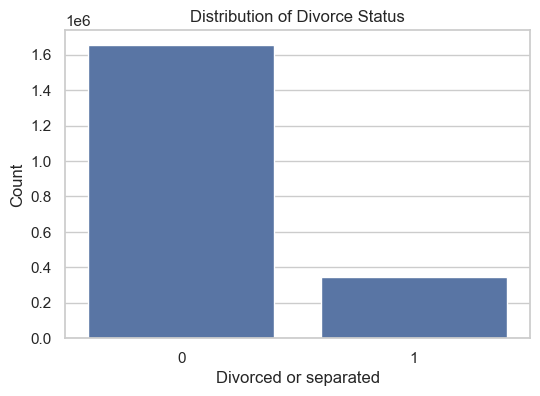

divorced
0    1656320
1     346072
Name: count, dtype: int64
divorced
0    0.827
1    0.173
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="divorced")
plt.title("Distribution of Divorce Status")
plt.xlabel("Divorced or separated")
plt.ylabel("Count")
plt.show()

print(df["divorced"].value_counts())
print(df["divorced"].value_counts(normalize=True).round(3))

## 5. Divorce Rate by Age Group

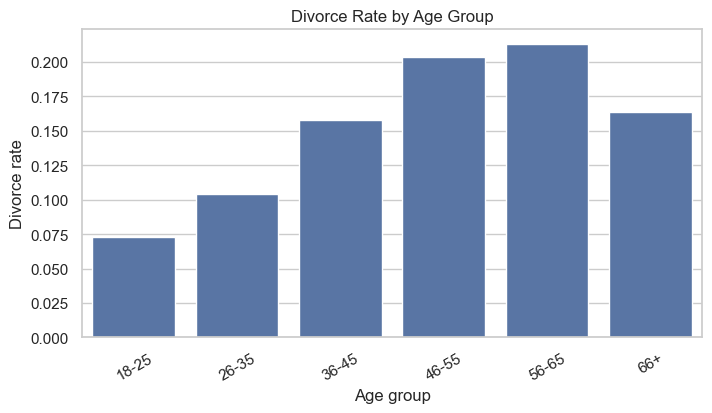

,age_group,divorced
0,18-25,0.072649
1,26-35,0.104251
2,36-45,0.158038
3,46-55,0.203326
4,56-65,0.212838
5,66+,0.163323


In [12]:
if "age_group" in df.columns:
    age_rates = df.groupby("age_group", observed=False)["divorced"].mean().reset_index()

    plt.figure(figsize=(8,4))
    sns.barplot(data=age_rates, x="age_group", y="divorced")
    plt.title("Divorce Rate by Age Group")
    plt.xlabel("Age group")
    plt.ylabel("Divorce rate")
    plt.xticks(rotation=30)
    plt.show()

    display(age_rates)

## 6. Divorce Rate by Education

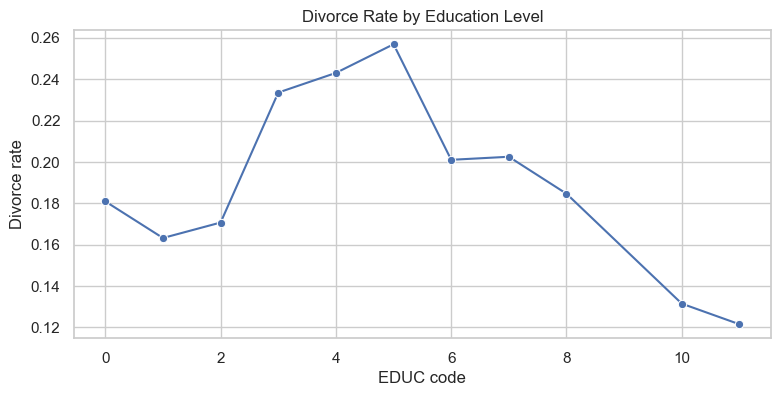

,EDUC,divorced
0,0,0.180919
1,1,0.163230
2,2,0.170710
3,3,0.233517
4,4,0.243011


In [14]:
if "EDUC" in df.columns:
    educ_rates = df.groupby("EDUC")["divorced"].mean().reset_index()

    plt.figure(figsize=(9,4))
    sns.lineplot(data=educ_rates, x="EDUC", y="divorced", marker="o")
    plt.title("Divorce Rate by Education Level")
    plt.xlabel("EDUC code")
    plt.ylabel("Divorce rate")
    plt.show()

    display(educ_rates.head())

## 7. Income and Divorce

I use log income because wage income is very skewed. This makes the distribution easier to compare.

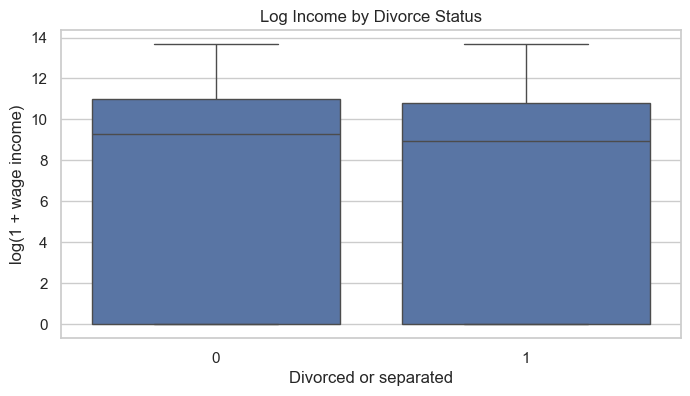

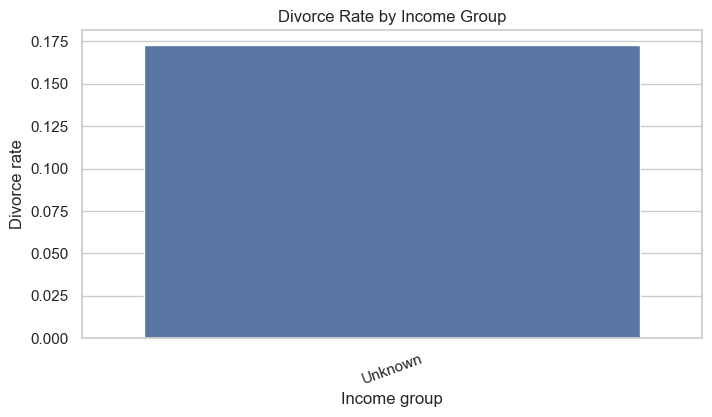

,income_group,divorced
0,Unknown,0.172829


In [16]:
if "log_income" in df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x="divorced", y="log_income")
    plt.title("Log Income by Divorce Status")
    plt.xlabel("Divorced or separated")
    plt.ylabel("log(1 + wage income)")
    plt.show()

if "income_group" in df.columns:
    income_rates = df.groupby("income_group", observed=False)["divorced"].mean().reset_index()

    plt.figure(figsize=(8,4))
    sns.barplot(data=income_rates, x="income_group", y="divorced")
    plt.title("Divorce Rate by Income Group")
    plt.xlabel("Income group")
    plt.ylabel("Divorce rate")
    plt.xticks(rotation=20)
    plt.show()

    display(income_rates)

## 8. Employment and Divorce

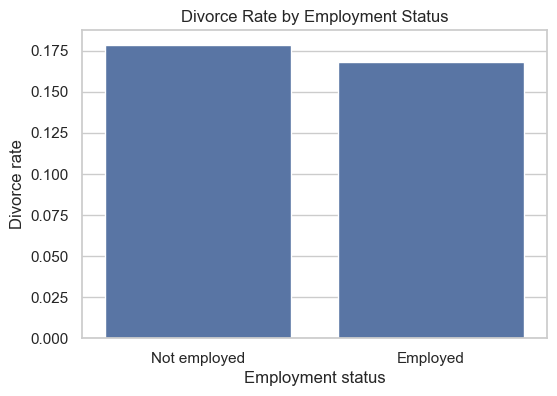

,employed,divorced,employment_status
0,0,0.178497,Not employed
1,1,0.168140,Employed


In [18]:
if "employed" in df.columns:
    emp_rates = df.groupby("employed")["divorced"].mean().reset_index()
    emp_rates["employment_status"] = emp_rates["employed"].map({0: "Not employed", 1: "Employed"})

    plt.figure(figsize=(6,4))
    sns.barplot(data=emp_rates, x="employment_status", y="divorced")
    plt.title("Divorce Rate by Employment Status")
    plt.xlabel("Employment status")
    plt.ylabel("Divorce rate")
    plt.show()

    display(emp_rates)

## 9. Correlation Heatmap

This gives a quick view of linear relationships between the numeric variables used in the project.

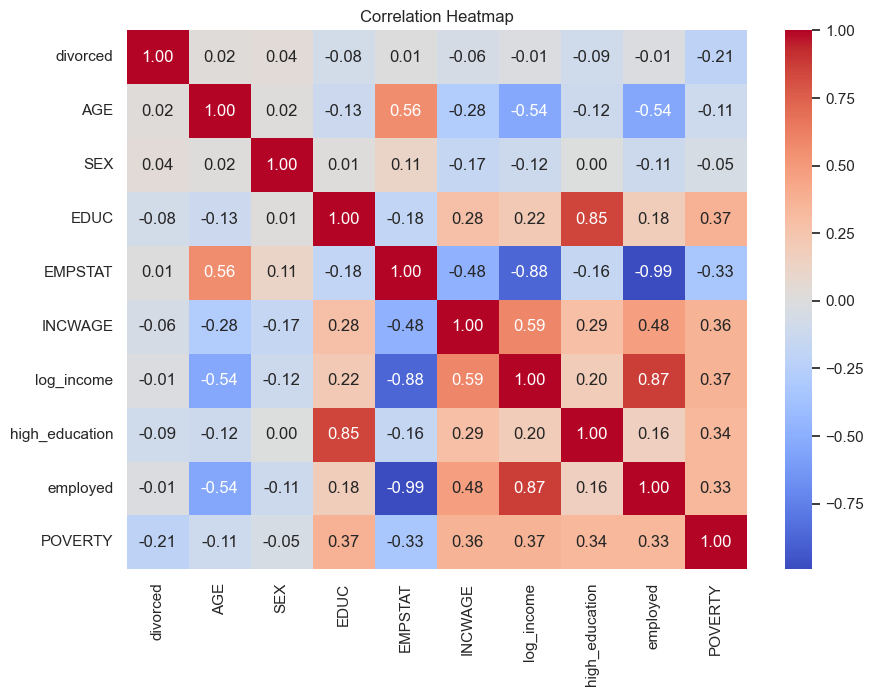

In [20]:
numeric_cols = [
    col for col in [
        "divorced", "AGE", "SEX", "EDUC", "EMPSTAT", "INCWAGE", "log_income",
        "high_education", "employed", "POVERTY", "WKSWORK2", "UHRSWORK"
    ]
    if col in df.columns
]

corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 10. Simple Statistical Checks

These tests are not used as proof of causality. I use them only as supporting evidence for the patterns seen in the charts.

In [22]:
# Chi-square test for education group and divorce
if "high_education" in df.columns:
    table = pd.crosstab(df["high_education"], df["divorced"])
    chi2, p, dof, expected = chi2_contingency(table)
    print("Chi-square test: high education vs divorce")
    print("p-value:", p)

# Mann-Whitney U test for income differences
if "log_income" in df.columns:
    group0 = df.loc[df["divorced"] == 0, "log_income"].dropna()
    group1 = df.loc[df["divorced"] == 1, "log_income"].dropna()
    stat, p = mannwhitneyu(group0, group1, alternative="two-sided")
    print("Mann-Whitney U test: log income by divorce status")
    print("p-value:", p)

Chi-square test: high education vs divorce
p-value: 0.0
Mann-Whitney U test: log income by divorce status
p-value: 0.0


## 11. EDA Summary

The EDA suggests that divorce status is connected with multiple demographic and socio-economic variables together rather than a single factor alone. Age, education, employment, income level, and grouped income/age categories all show different patterns related to divorce status. 

The analysis also shows that relationships between variables are often interconnected. Because of this, the machine learning section uses both original IPUMS variables and engineered features such as log-transformed income, grouped variables, interaction features, and ratio-based features instead of relying only on a small set of basic predictors.

These findings do not prove causality, but they help identify meaningful patterns that can improve predictive modeling and provide a broader understanding of divorce-related socio-economic trends.